### Register and preprocess AINI-Stroke AIT images


In [18]:
import os
import glob

import ants

import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

import nibabel as nib

import SimpleITK as sitk

from skimage.transform import resize

from concurrent.futures import ProcessPoolExecutor, as_completed

In [2]:
#ROOT_DIR = "/home/fehrdelt/bettik/"
ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"

In [3]:
def resample_img(itk_image, out_spacing=[1.0, 1.0, 1.0]):
    # Resample images to 2mspecified spacing with SimpleITK

    original_spacing = itk_image.GetSpacing()
    original_size = itk_image.GetSize()

    out_size = [
        int(np.round(original_size[0] * (original_spacing[0] / out_spacing[0]))),
        int(np.round(original_size[1] * (original_spacing[1] / out_spacing[1]))),
        int(np.round(original_size[2] * (original_spacing[2] / out_spacing[2])))]

    resample = sitk.ResampleImageFilter()
    resample.SetOutputSpacing(out_spacing)
    resample.SetSize(out_size)
    resample.SetOutputDirection(itk_image.GetDirection())
    resample.SetOutputOrigin(itk_image.GetOrigin())
    resample.SetTransform(sitk.Transform())
    resample.SetDefaultPixelValue(itk_image.GetPixelIDValue())


    resample.SetInterpolator(sitk.sitkBSpline)

    return resample.Execute(itk_image)

In [4]:
def register_nifti_files(fixed_reference, dataset_path, output_path, register_masks=False, dataset_masks_path=None, output_masks_path=None):
    """
    Registers all NIfTI files in the dataset_path folder to the same space using ANTs.

    Parameters:
    - dataset_path: Path to the folder containing NIfTI files.
    - output_path: Path to save the registered NIfTI files.
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_path, exist_ok=True)

    # Get all NIfTI files in the dataset_path
    nifti_files = sorted(glob.glob(os.path.join(dataset_path, "*.nii*")))
    if register_masks:
        nifti_masks_files = sorted(glob.glob(os.path.join(dataset_masks_path, "*.nii*")))
    #print("nifti_files", nifti_files)
    if register_masks: print("nifti_masks_files", nifti_masks_files)
    if not nifti_files:
        print("No NIfTI files found in the dataset path.")
        return

    # Use the first file as the fixed image (reference)
    fixed_image = ants.image_read(fixed_reference)

    for i, moving_file in enumerate(tqdm(nifti_files)):
        
        output_filepath = os.path.join(output_path, os.path.basename(moving_file))

        if register_masks:
            mask_file = nifti_masks_files[i]
            output_mask_filepath = os.path.join(output_masks_path, os.path.basename(mask_file))
        
        
        if not os.path.isfile(output_filepath):
            moving_image = ants.image_read(moving_file)
            
            # Perform registration
            registration = ants.registration(fixed=fixed_image, moving=moving_image, type_of_transform='Similarity') # https://antspy.readthedocs.io/en/latest/registration.html types of transforms

            # for the mask
            if register_masks:
                mask_image = ants.image_read(mask_file)
                transform = registration['fwdtransforms']
                mask_moved = ants.apply_transforms(fixed_image, mask_image, transformlist=transform, interpolation='nearestNeighbor')
                mask_moved.to_file(output_mask_filepath)

            # Save the registered image
            ants.image_write(registration['warpedmovout'], output_filepath)
    
            #print(f"Registered {moving_file} and saved to {output_filepath}")
        else:
            print("skipped registration already done")


### ADC

In [5]:
ait_adc_unprocessed_folder = ROOT_DIR+"datasets/aini-stroke_ait/adc_skullstrip/"

ait_adc_resampled_output_folder = ROOT_DIR+"datasets/aini-stroke_ait/adc_skullstrip_resampled/"
os.makedirs(ait_adc_resampled_output_folder, exist_ok=True)

ait_adc_final_output_folder_resized = ROOT_DIR+"datasets/aini-stroke_ait/adc_resized/"
os.makedirs(ait_adc_final_output_folder_resized, exist_ok=True)

ait_adc_final_output_folder_registered = ROOT_DIR+"datasets/aini-stroke_ait/adc_registered/"
os.makedirs(ait_adc_final_output_folder_registered, exist_ok=True)

#### Visualize unprocessed ADC AIT images

Image 1 shape: (280, 280, 36)
Image 2 shape: (280, 280, 36)
Image 3 shape: (280, 280, 36)
Image 4 shape: (280, 280, 36)


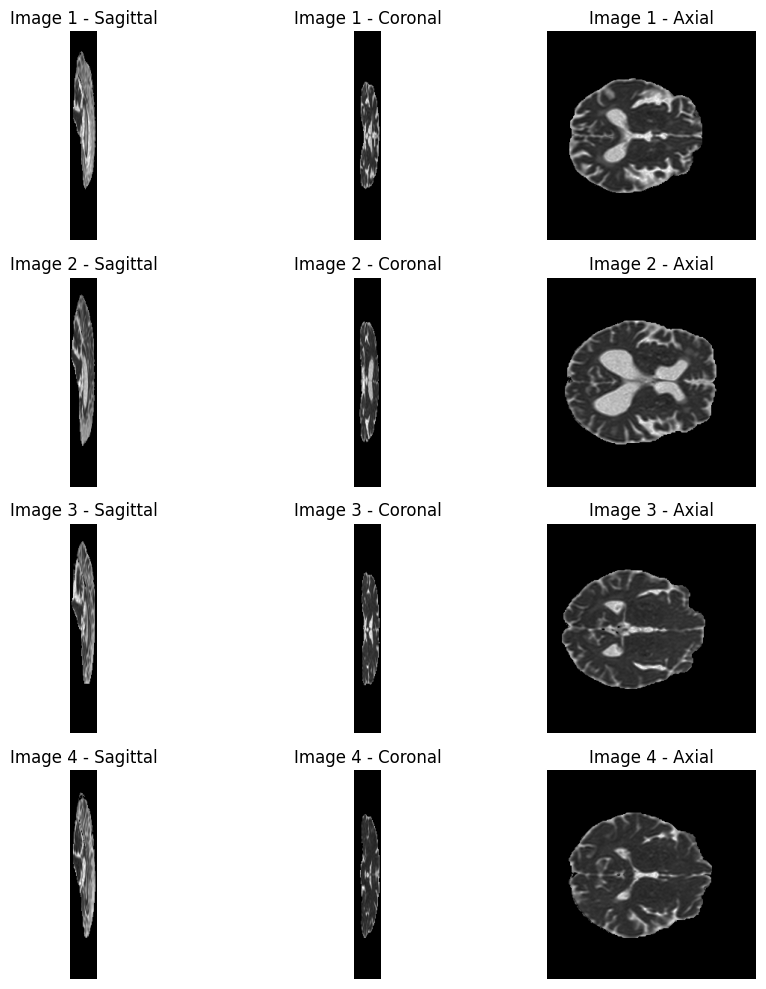

In [ ]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(ait_adc_unprocessed_folder, "*.nii.gz")))[:4]

# Plot the images
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [14]:
for image_path in tqdm(glob.glob(os.path.join(ait_adc_folder, "*.nii.gz"))):
    itk_image = sitk.ReadImage(image_path)
    resampled_image = resample_img(itk_image)
    output_path = os.path.join(ait_adc_resampled_output_folder, os.path.basename(image_path))
    sitk.WriteImage(resampled_image, output_path)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 75/75 [00:43<00:00,  1.74it/s]


Image 1 shape: (240, 240, 158)
Image 2 shape: (230, 230, 158)
Image 3 shape: (230, 230, 158)
Image 4 shape: (230, 230, 158)


<Figure size 640x480 with 0 Axes>

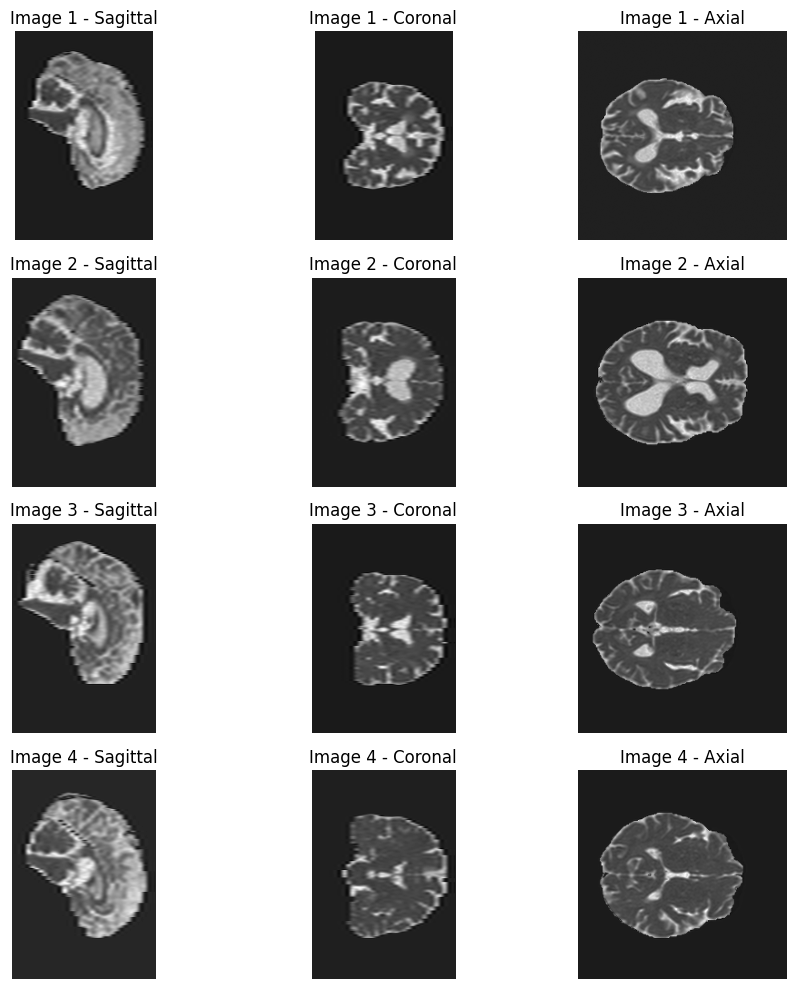

In [15]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(ait_adc_resampled_output_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Aini-Stroke AIT Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# pad to (230, 230, 230) and resize to (128, 128, 128)
os.makedirs(ait_adc_resampled_output_folder, exist_ok=True)

nifti_files = sorted(glob.glob(os.path.join(ait_adc_resampled_output_folder, "*.nii.gz")))
os.makedirs(ait_adc_final_output_folder_resized, exist_ok=True)

for file_path in tqdm(nifti_files):
    out_path = os.path.join(ait_adc_final_output_folder_resized, os.path.basename(file_path))
    if True: #not os.path.exists(out_path):
        img = nib.load(file_path)
        data = img.get_fdata()
        
        original_shape = data.shape

        # Calculate padding for each dimension
        pad_width = []
        for orig, target in zip(original_shape, (230, 230, 230)):
            total_pad = max(target - orig, 0)
            before = total_pad // 2
            after = total_pad - before
            pad_width.append((before, after))

        # Pad the image
        data = np.pad(data, pad_width, mode='constant', constant_values=0)

        data = resize(data, (128, 128, 128), anti_aliasing=True)

        # Save padded image
        padded_img = nib.Nifti1Image(data, img.affine, img.header)
        
        nib.save(padded_img, out_path)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 75/75 [00:47<00:00,  1.56it/s]


Image 1 shape: (128, 128, 128)
Image 2 shape: (128, 128, 128)
Image 3 shape: (128, 128, 128)
Image 4 shape: (128, 128, 128)


<Figure size 640x480 with 0 Axes>

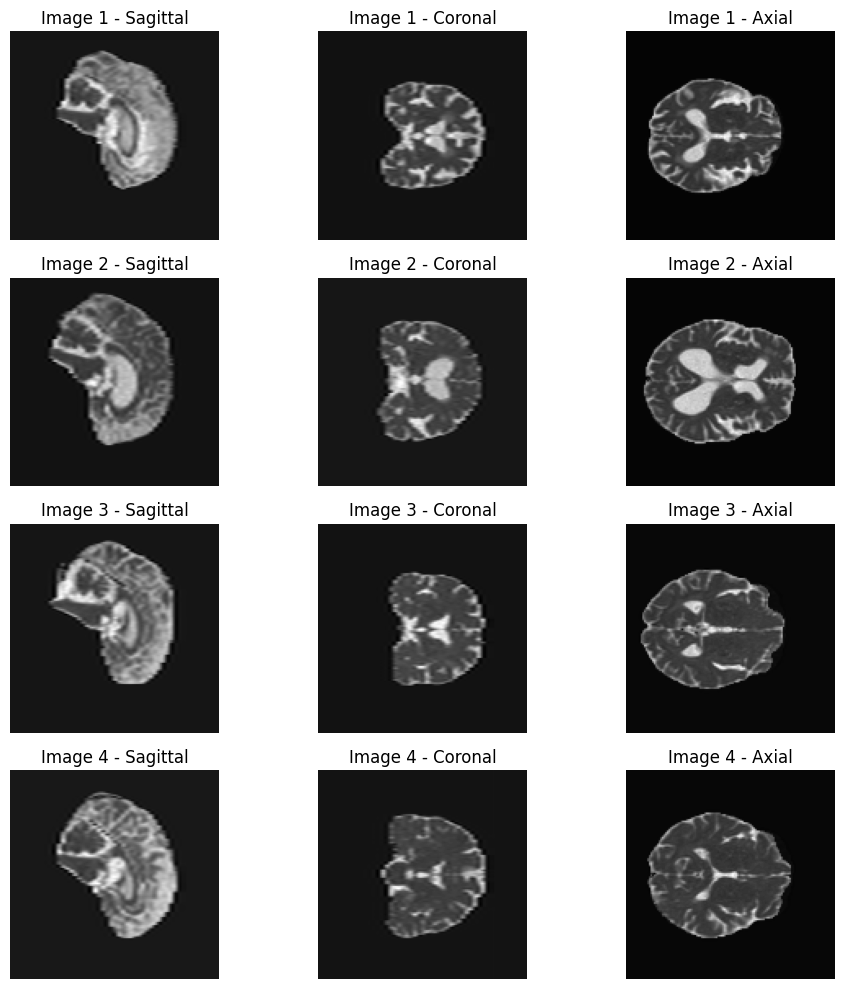

In [ ]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(ait_adc_final_output_folder_resized, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Aini-Stroke AIT Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [23]:

register_nifti_files(fixed_reference=ROOT_DIR+"datasets/mni_icbm152_nlin_sym_09a/128_hist_match_to_hcp_ya_FINAL_mni_icbm152_t2.nii.gz", 
                     dataset_path=ait_adc_final_output_folder_resized, 
                     output_path=ait_adc_final_output_folder_registered)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 75/75 [02:30<00:00,  2.00s/it]


Image 1 shape: (128, 128, 128)
Image 2 shape: (128, 128, 128)
Image 3 shape: (128, 128, 128)
Image 4 shape: (128, 128, 128)


<Figure size 640x480 with 0 Axes>

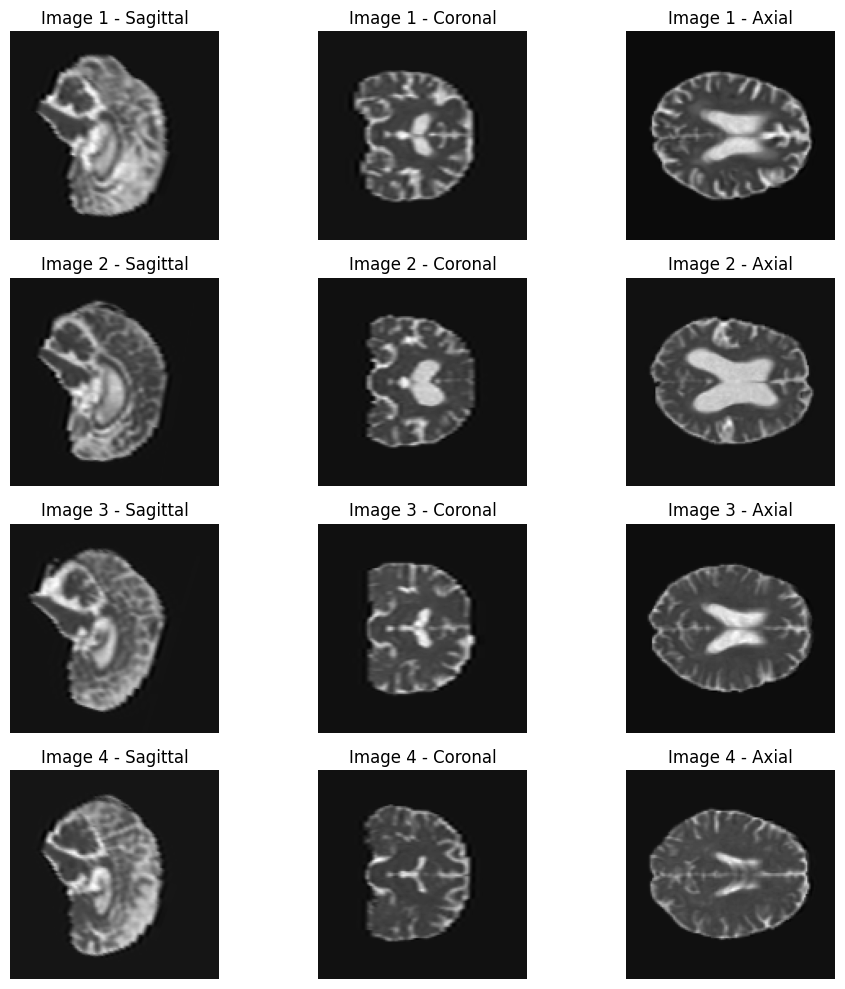

In [24]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(ait_adc_final_output_folder_registered, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Aini-Stroke AIT Registered Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [6]:
ait_flair_unprocessed_folder = ROOT_DIR+"datasets/aini-stroke_ait/flair_skullstrip/"

ait_flair_resampled_output_folder = ROOT_DIR+"datasets/aini-stroke_ait/flair_skullstrip_resampled/"
os.makedirs(ait_flair_resampled_output_folder, exist_ok=True)

ait_flair_final_output_folder_resized = ROOT_DIR+"datasets/aini-stroke_ait/flair_resized/"
os.makedirs(ait_flair_final_output_folder_resized, exist_ok=True)

ait_flair_final_output_folder_registered = ROOT_DIR+"datasets/aini-stroke_ait/flair_registered/"
os.makedirs(ait_flair_final_output_folder_registered, exist_ok=True)

#### Visualize unprocessed ADC AIT images

Image 1 shape: (256, 256, 35)
Image 2 shape: (256, 256, 35)
Image 3 shape: (256, 256, 35)
Image 4 shape: (256, 256, 35)


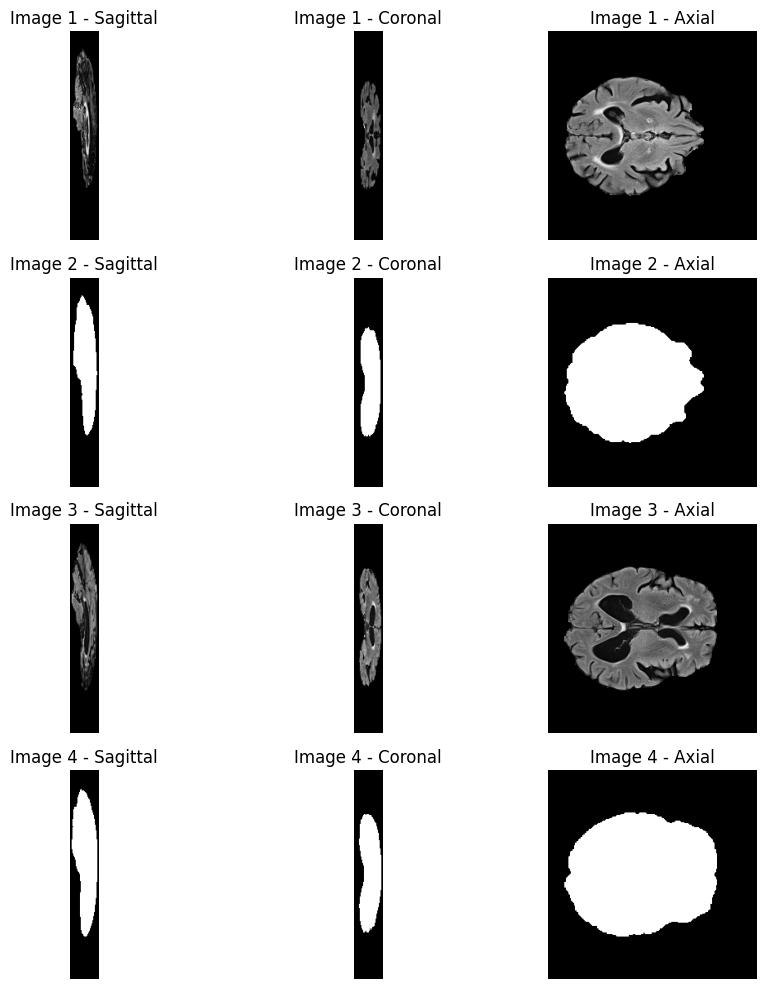

In [6]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(ait_flair_unprocessed_folder, "*.nii.gz")))[:4]

# Plot the images
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [8]:
for image_path in tqdm(glob.glob(os.path.join(ait_flair_unprocessed_folder, "*.nii.gz"))):
    itk_image = sitk.ReadImage(image_path)
    resampled_image = resample_img(itk_image)
    output_path = os.path.join(ait_flair_resampled_output_folder, os.path.basename(image_path))
    sitk.WriteImage(resampled_image, output_path)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 102/102 [01:45<00:00,  1.03s/it]


Image 1 shape: (230, 230, 154)
Image 2 shape: (230, 230, 154)
Image 3 shape: (230, 230, 154)
Image 4 shape: (230, 230, 154)


<Figure size 640x480 with 0 Axes>

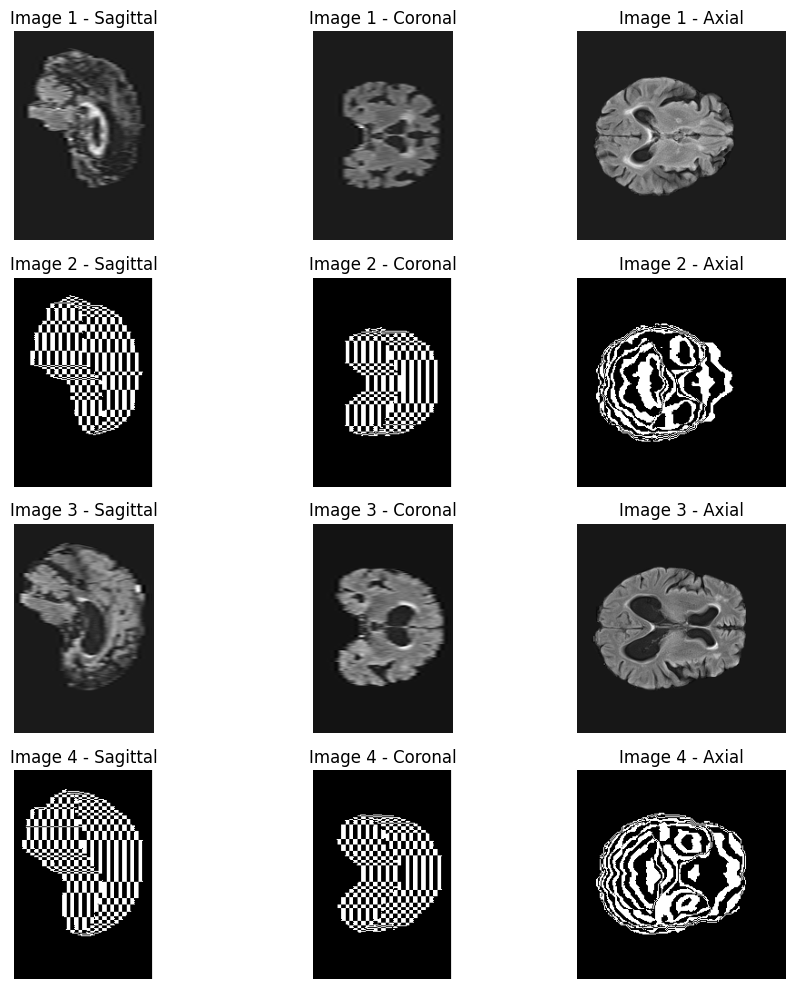

In [9]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(ait_flair_resampled_output_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Aini-Stroke AIT FLAIR Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [10]:
# pad to (230, 230, 230) and resize to (128, 128, 128)
os.makedirs(ait_flair_resampled_output_folder, exist_ok=True)

nifti_files = sorted(glob.glob(os.path.join(ait_flair_resampled_output_folder, "*.nii.gz")))
os.makedirs(ait_flair_final_output_folder_resized, exist_ok=True)

for file_path in tqdm(nifti_files):
    out_path = os.path.join(ait_flair_final_output_folder_resized, os.path.basename(file_path))
    if True: #not os.path.exists(out_path):
        img = nib.load(file_path)
        data = img.get_fdata()
        
        original_shape = data.shape

        # Calculate padding for each dimension
        pad_width = []
        for orig, target in zip(original_shape, (230, 230, 230)):
            total_pad = max(target - orig, 0)
            before = total_pad // 2
            after = total_pad - before
            pad_width.append((before, after))

        # Pad the image
        data = np.pad(data, pad_width, mode='constant', constant_values=0)

        data = resize(data, (128, 128, 128), anti_aliasing=True)

        # Save padded image
        padded_img = nib.Nifti1Image(data, img.affine, img.header)
        
        nib.save(padded_img, out_path)

  0%|                                                                                                                                                                                        | 0/102 [00:00<?, ?it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 102/102 [01:01<00:00,  1.66it/s]


Image 1 shape: (128, 128, 128)
Image 2 shape: (128, 128, 128)
Image 3 shape: (128, 128, 128)
Image 4 shape: (128, 128, 128)


<Figure size 640x480 with 0 Axes>

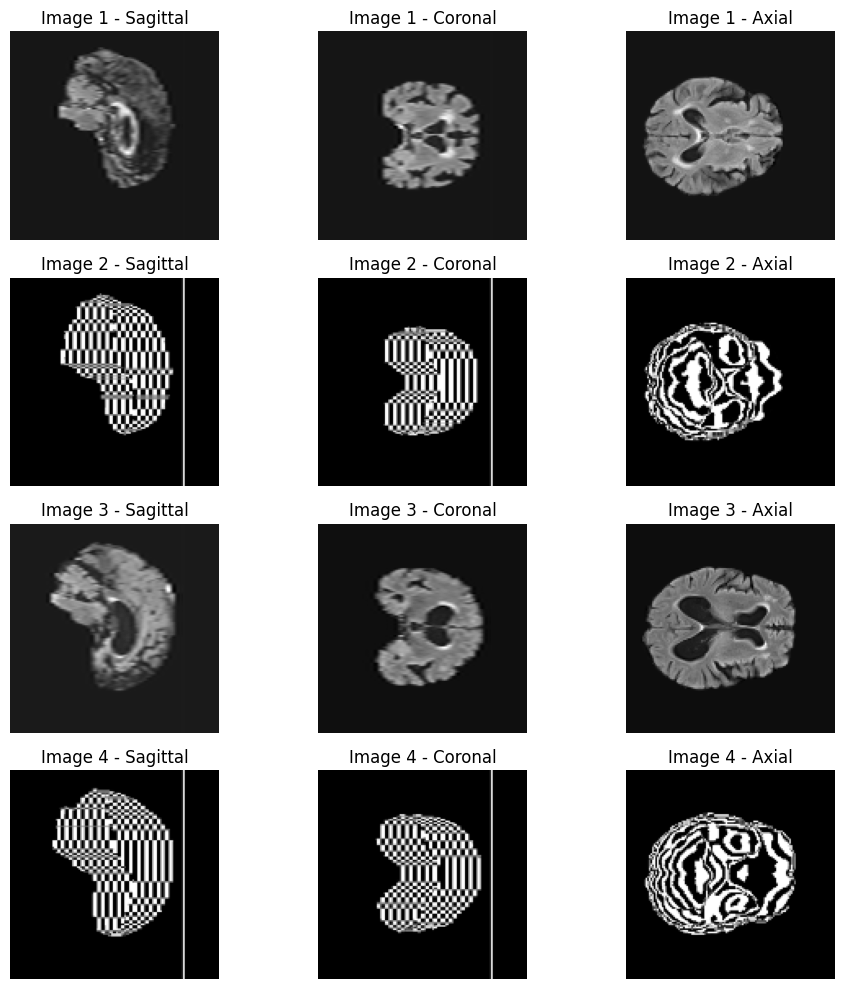

In [11]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(ait_flair_final_output_folder_resized, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Aini-Stroke AIT FLAIR Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [12]:

register_nifti_files(fixed_reference=ROOT_DIR+"datasets/mni_icbm152_nlin_sym_09a/128_hist_match_to_hcp_ya_FINAL_mni_icbm152_t2.nii.gz", 
                     dataset_path=ait_flair_final_output_folder_resized, 
                     output_path=ait_flair_final_output_folder_registered)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 102/102 [03:45<00:00,  2.22s/it]


Image 1 shape: (128, 128, 128)
Image 2 shape: (128, 128, 128)
Image 3 shape: (128, 128, 128)
Image 4 shape: (128, 128, 128)


<Figure size 640x480 with 0 Axes>

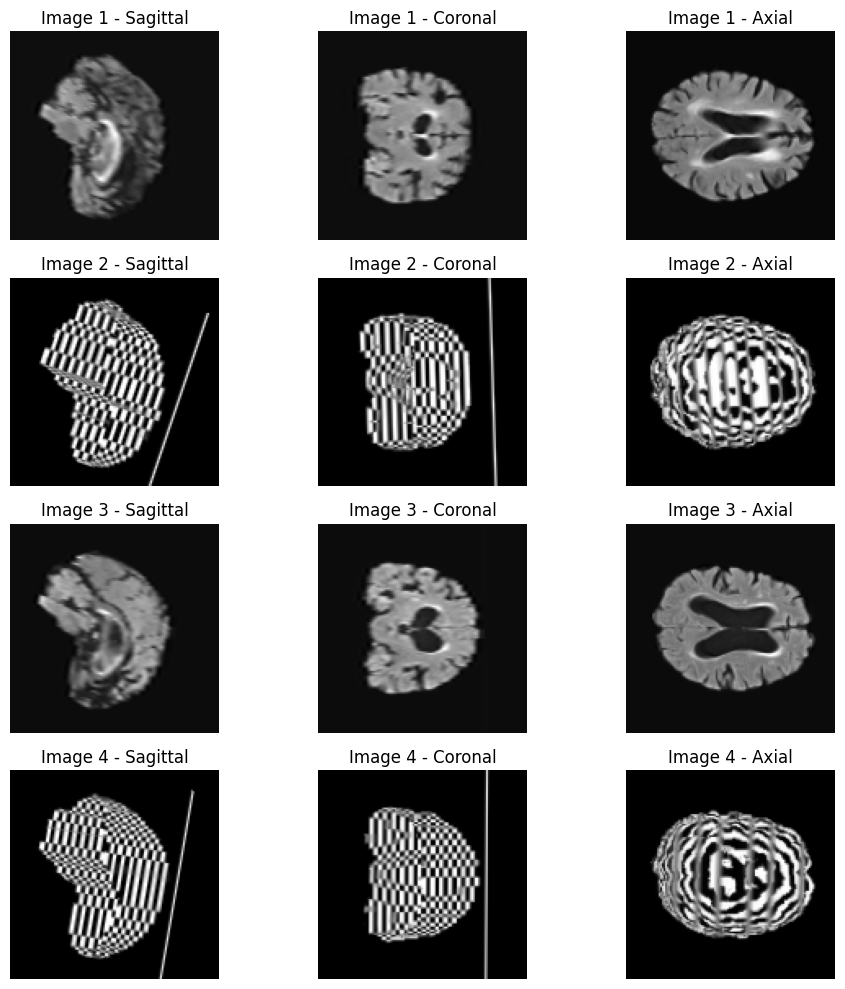

In [13]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(ait_flair_final_output_folder_registered, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Aini-Stroke AIT FLAIR images")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Get all image paths from the folder (excluding mask files)
image_paths = sorted([p for p in glob.glob(os.path.join(ait_flair_final_output_folder_registered, "*.nii.gz")) if "_mask" not in p])

# Calculate number of rows needed
n_images = len(image_paths)
n_cols = 3
n_rows = n_images

# Plot the images
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, n_rows * 2.5))
plt.suptitle(f"Aini-Stroke AIT FLAIR images - All {n_images} images")

for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    image_name = os.path.basename(image_path)
    print(f"Image {i+1} ({image_name}) shape: {image.shape}")
    
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"{image_name} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
bad_images_flair = ["aini-stroke_15092_12783", "aini-stroke_17043_12971", "aini-stroke_18254_13045"] # registration problems
bad_images_adc = ["aini-stroke_13607", "aini-stroke_21053"]

In [19]:
# Registration
def process_image_register(image_path, output_folder):

    fixed_image = ants.image_read(image_path)
    template_image = ants.image_read(ROOT_DIR+"datasets/mni_icbm152_nlin_sym_09a/128_mni_icbm152_t1_skullstrip.nii.gz")
    atlas_image = ants.image_read(ROOT_DIR+"datasets/registered_atlas_128.nii.gz")
    output_path = output_folder + f"/{os.path.basename(image_path)}"
    # if the output file already exists, skip
    if os.path.exists(output_path):
        return

    # Perform registration
    registration = ants.registration(fixed=fixed_image, moving=template_image, type_of_transform='antsRegistrationSyNsr') # https://antspy.readthedocs.io/en/latest/registration.html types of transforms

    # Apply the same transform to the atlas
    warped_atlas = ants.apply_transforms(fixed=fixed_image, moving=atlas_image, transformlist=registration['fwdtransforms'], interpolator='nearestNeighbor')
    ants.image_write(warped_atlas, output_path)


In [20]:


image_paths = glob.glob(os.path.join(ait_flair_final_output_folder_registered, "*.nii.gz"))

with ProcessPoolExecutor(max_workers=16) as executor:
    futures = {executor.submit(process_image_register, path, ROOT_DIR+"datasets/aini-stroke_ait/registered_atlases/"): path for path in image_paths}

    for future in tqdm(as_completed(futures), total=len(futures), desc="Processing images"):
        _ = future.result()

Processing images: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 51/51 [54:12<00:00, 63.77s/it]
